In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych i poprawne parsowanie czasu
# Używamy pd.to_datetime, aby poprawnie obliczyć dt w sekundach

dane_normalne = pd.read_excel("Przebieg normalny.xlsx")
dane_zaburzone = pd.read_excel("Przebieg zaburzony.xlsx")


dodanie wyświetlenia kolumn  i dodanie czasu z pliku a nie dt=1

In [37]:
dt = 1

def przygotuj_sygnaly(df):
    # Temperatury y i z dzielimy przez 10 (zgodnie z wytycznymi: 235 -> 23.5)
    temp_obiektu = df["y (T)"].values / 10.0
    temp_otoczenia = df["z (Tz)"].values / 10.0
    moc_grzalki = df["u (Pg)"].values
    return temp_obiektu, temp_otoczenia, moc_grzalki

y_norm, z_norm, u_norm = przygotuj_sygnaly(dane_normalne)
y_zab, z_zab, u_zab = przygotuj_sygnaly(dane_zaburzone)

In [38]:
# Zad 1 i 2: Wyznaczenie parametrów c i d metodą MNK
# Model dyskretny: y[n+1] = y[n] + (Δt/c)*u[n] + (d*Δt/c)*(z[n] - y[n])
# Równanie regresji:  y[n+1] -y[n] = a*u + b*(z-y)
# gdzie paramtery pomocnicze to: a = Δt/c, b = (d*Δt)/c


roznica_y = y_norm[1:] - y_norm[:-1] # y[n+1] - y[n]
macierz_wejsciowa = np.column_stack([
    u_norm[:-1], 
    z_norm[:-1] - y_norm[:-1]
])

DO poprawy Równanie regresyjne:
y[n+1] - y[n] = au[n] + b(z[n] - y[n])
Y = y_norm[1:] - y_norm[:-1]

Phi = np.column_stack([
    u_norm[:-1],
    z_norm[:-1] - y_norm[:-1]
])

LS: theta = (Phi^T Phi)^(-1) Phi^T Y
theta = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ Y

a, b = theta

Odzyskanie parametrów fizycznych
c = dt / a
d = b / a

In [40]:
# Rozwiązanie układu - Metoda Najmniejszych Kwadratów
parametry_pomocnicze, _, _, _ = np.linalg.lstsq(macierz_wejsciowa, roznica_y, rcond=None)
a_mnk, b_mnk = parametry_pomocnicze

#wyliczenie parametrów fizycznych c i d
#c to Δt/a, d=b/a
c_wynik = dt / a_mnk
d_wynik = b_mnk / a_mnk

print(f"Parametry pomocnicze a i b : a = {a_mnk:.10f}, b = {b_mnk:.10f}")
print(f"Zidentyfikowane parametry: c = {c_wynik:.4f}, d = {d_wynik:.4f}")

Parametry pomocnicze a i b : a = 0.0000394028, b = 0.0004157270
Zidentyfikowane parametry: c = 25378.8876, d = 10.5507


In [215]:
# Zad 3: Predykcja z horyzontem h
def oblicz_predykcje(y_dane, u_dane, z_dane, a, b, horyzont):
    n_probek = len(y_dane)
    y_pred = np.full(n_probek, np.nan)
    
    # Zgodnie z Rys. 1: startujemy z rzeczywistego y[n-h] i robimy h kroków modelem
    for n in range(horyzont, n_probek):
        wartosc_startowa = y_dane[n - horyzont]
        temp_sym = wartosc_startowa
        
        for k in range(horyzont):
            idx = n - horyzont + k
            # Iteracja modelu dyskretnego
            temp_sym = temp_sym + a * u_dane[idx] + b * (z_dane[idx] - temp_sym)
        
        y_pred[n] = temp_sym
    return y_pred

horyzonty = [ 1,5,10,30, 60]
wyniki_predykcji = {h: oblicz_predykcje(y_norm, u_norm, z_norm, a_mnk, b_mnk, h) for h in horyzonty}#do zminy kod 

# for h in horyzonty:
#     y_hat = wyniki_predykcji[h]
#     
#     print(f"Predykcja wyjścia ŷ_n dla h = {h}")
#     print("n\tŷ_n")
#     
#     for n in range(h, len(y_hat)):
#         print(f"{n}\t{y_hat[n]:.3f}")

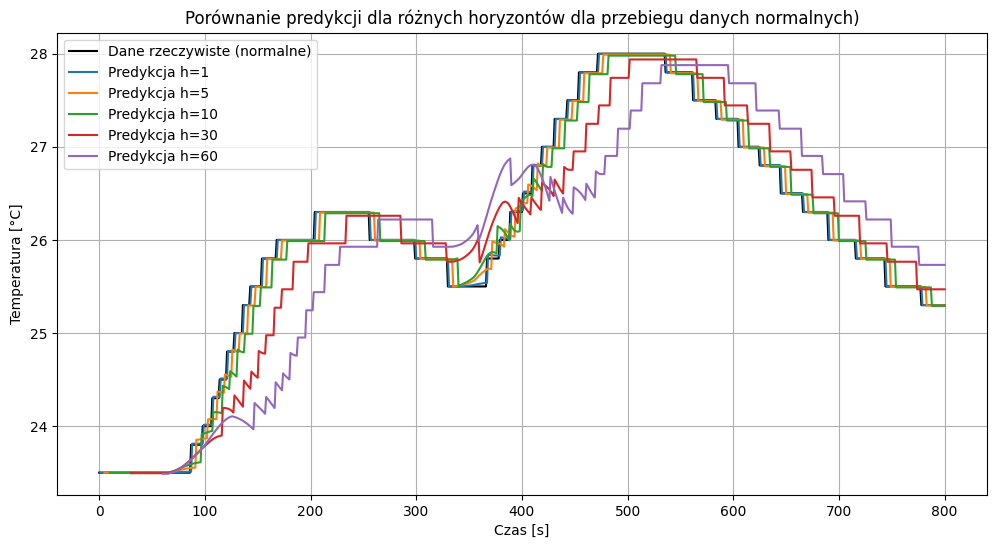

In [211]:
# przebieg rzeczywisty i przebiegi przewidywane -wykres porównawczy predykcji
plt.figure(figsize=(12, 6))
plt.plot(y_norm, label="Dane rzeczywiste (normalne)", color='black',  linewidth=1.5)
for h in horyzonty:
    plt.plot(wyniki_predykcji[h], label=f"Predykcja h={h}")
plt.title("Porównanie predykcji dla różnych horyzontów dla przebiegu danych normalnych)")
plt.xlabel("Czas [s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()

Dla h równego 1 widać dobre pokrycie, prawie idealne dopasowania z tego powodu, że predykcja tylko o 1 próbkę w przód. Przy h=5 widać pierwsze delikatne odchylenia od danych normalnych. 

DLa h = 10 zaczyna się kumulacja błedów, odchylenie w czasie jest większe - przez co bardziej widoczne na wykresie. Natomiast wciąż dobrze odwzorowuje zmiany temperturowe. 

dla h = 30 widać znaczne odchylenie oraz brak poprawnego odwzorowania na przykład w trakcie grzania 380 sekundzie widać znaczną różnice w zachowaniu predykowanych danych w stosunku do danych normalnych. 

dla h=60 - dużym horyzoncie predykcji można zauwazyć znaczną różnicę między przebiegiem rzeczywistym a przebiegiem przewidywanym - między innymi w t = 380 predykowane wygładza wykres?

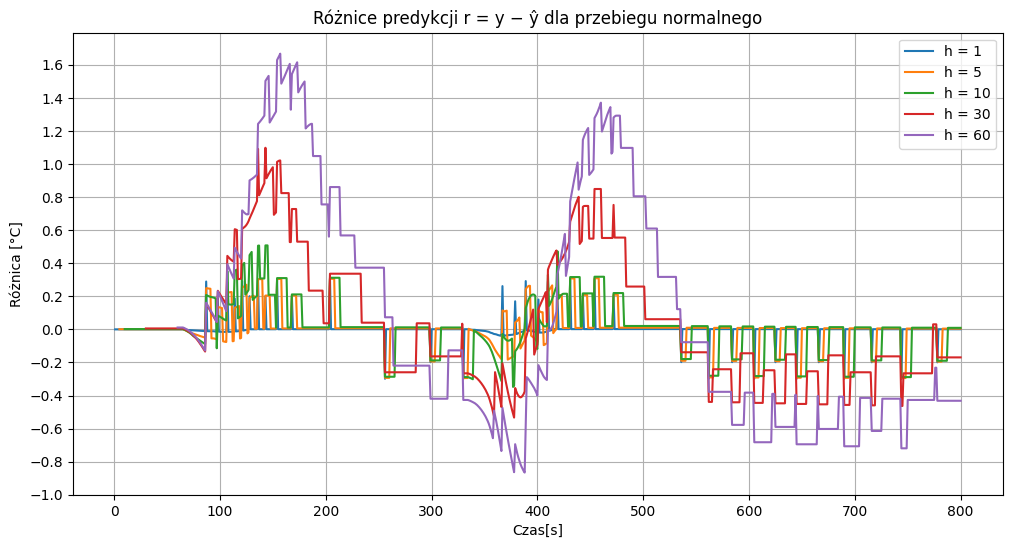

In [212]:
# CZĘŚĆ (ii)
#  Zad.1: reszty dla przebiegu normalnego 
reszty_normalne = {}

for h in horyzonty:
    y_pred = wyniki_predykcji[h]
    reszty_normalne[h] = y_norm - y_pred


plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_normalne[h], label=f"h = {h}")
plt.title("Różnice predykcji r = y − ŷ dla przebiegu normalnego")
plt.xlabel("Czas[s]")
plt.yticks(np.arange(-1, 1.8, 0.2))
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()

Wykres przebiegu rn - różnicy rzeczywistej wartości wyjścia od przewidywanej wartości wyjścia. Widocznie obrazuje okresy czasu, w których predykowane wartości są zawyżane - rekorody poniżej wartości 0.0 na osi Różnicy lub zaniżane - rekorody powyżej wartości 0.0 na osi Różnicy.

Dla małego horyzontu predykcji (h=1) różnica jest nieduża (dla h=1 różnica wynosi maksymalnie 0.3°C - małe kroki powodują małe błędy ponieważ model jest cały czas korygowany pomiarem.

Dla h=5 również różnica jest niewielka jednak odchylenia są bardziej widoczne ponieważ korekta jest co 5 próbek (sekund).
Dla h=10 - dłuższy brak korzystania z danych rzeczywistych sprawia, że wartość różnicy dochodzi do wartości 0.5°C - natomiast przy dłuższych okresach czasu występowania jednakowej temperatury przebieg przewidywany stara się upodobnić do przebiegu rzeczywistego
Dla h=30 - niekorzystanie przez 30s z rzeczywistych pomiarów y  sprawia, że przebieg przewidywany ma problem z pokrywaniem się z przebiegiem rzeczywistym - w pojedynczych momentach różnica wynosi ponad 1.1°C. Przebieg przewidywany jedynie kilka razy był w stanie doprowadzić do różnicy równej 0. 
Dla h=60 - tak długi horyzont predykcji odpowiada całym epizodom grzania przez co różnice przebiegu przewidywanego z rzeczywistym jest duża - może wynosić momentami ponad 1.6°C. 




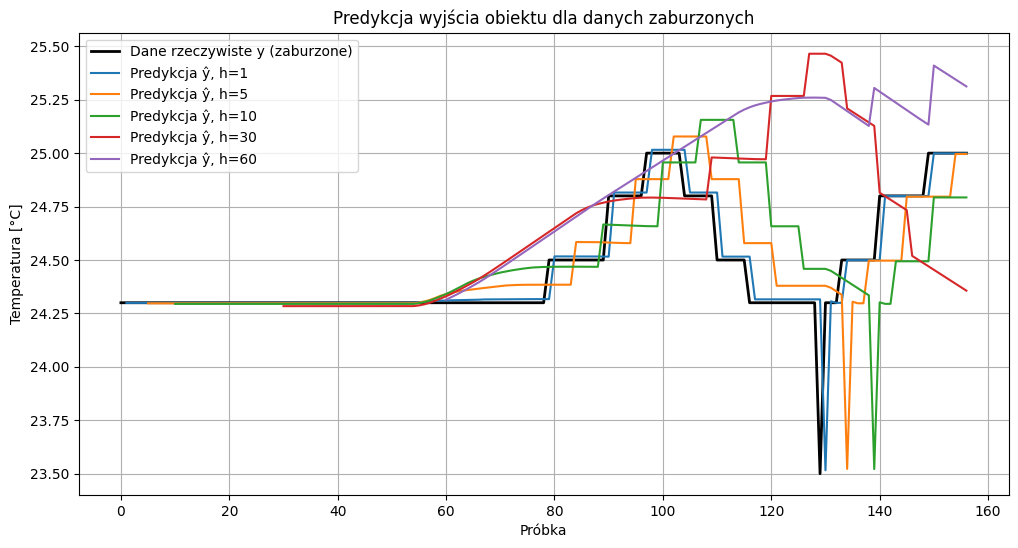

In [213]:
# Zad.2: predykcja dla danych zaburzonych - dużo mniej próbek - tylko 157 gdzie w normalnym wynosiła ponad 800
predykcje_zaburzone = {}
reszty_zaburzone = {}

for h in horyzonty:
    y_pred_zab = oblicz_predykcje(y_zab, u_zab, z_zab, a_mnk, b_mnk, h)
    predykcje_zaburzone[h] = y_pred_zab
    reszty_zaburzone[h] = y_zab - y_pred_zab
    

plt.figure(figsize=(12, 6))
plt.plot(y_zab, label="Dane rzeczywiste y (zaburzone)", linewidth=2, color='black')

for h in horyzonty:
    plt.plot(predykcje_zaburzone[h], label=f"Predykcja ŷ, h={h}")

plt.title("Predykcja wyjścia obiektu dla danych zaburzonych")
plt.xlabel("Próbka")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()


Zaobserwowano znaczny spadek temperatury w 130 sekundzie - nie wynika on jednak z włączenia grzałki czy wentylatora tylko najprawdopodobniej z błędu pomiarowego. Epizod włączenia wentylatora w 97 sekundzie przy jednoczesnej stałej mocy grzałki od 90 do 130 sekundzie wynoszącej 417 W zaczął wpływac na spadek temperatury dopiero w 105 sekundzie. 

dla h=1 zaobserwowano jak w przypadku danych normalnych, że tak mały horyzont predykcji sprawia, że cały czas wykorzystywane są pomiary bardzo bliskie aktualnym. Kształt wykresu jest niemal identyczny jak w przypadku danych rzeczywistych, jedynie lekko przesunięty.

dla h=5 widać pierwsze odchylenie - w 60 sekundzie - przebieg przewidywany zakładał wzrost temperatury w związku z rozpoczęciem zwiększenia mocy grzałki. Kształt wykresu pomimo tego jest wciąż podbny do przebiegu rzeczywistego.

dla h=10 odchylenie od przebiegu rzeczywistego jest większe, w niektórych okresach czasu przebieg przewiduje nieco inne ułożenie skoku. 

dla h=30 predykowany przebieg znaczanie różni się od przebiegu rzeczywistego, ponieważ przez 30 sekund - czyli prawie 20% kroków we wszystkich rekordach, model działa bez pomiarów obiektu. W związku z taką wartością horyzontu predykcji okres czasu, w którym wentylator został włączony (wynoszący 18 sekund) może zostać niewykorzystany w aktualizacji pomiarów. 

dla h=60  horyzont predykcji stanowi prawie 40% zakresu dostępnych danych pomiarowych zaobserwowano bardzo duży wzrost temperatury niepokrywający się z rzeczywistym przebiegiem - taka wartość h jest nieodpowiednia dla przebiegu o tak krótkim czasie. 

Warto zwrócić uwagę na to, że, zgodnie z poleceniem, zastosowano takie same wartości horyzontu predykcji dla analizy przebiegów: przebiegu normalnego jak i zaburzonego.  Liczba obserwacji w pomiarach przebiegu normalnego wynosiła 801, a przebiegu zaburzonego 157. Przez tę różnice w stosunkach dla horyzontu predykcji h = 60 nie jest możliwa ocena wpływu włączenia wentylatora na jakość predykcji, ponieważ przewidywany moment reakcji obiektu wykracza poza zakres dostępnych danych pomiarowych. 

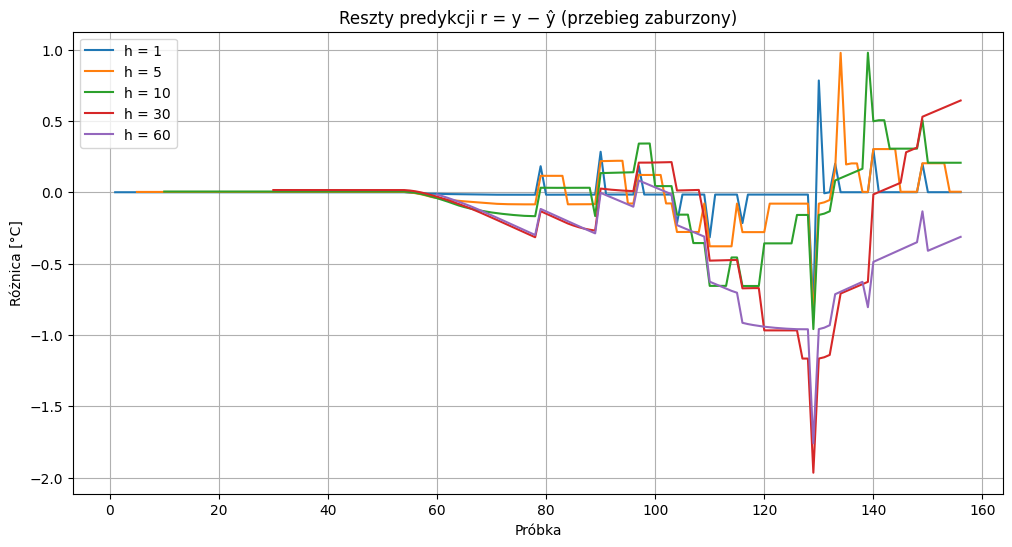

In [216]:

#Zad.3: reszty dla przebiegu zaburzonego
plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_zaburzone[h], label=f"h = {h}")
plt.title("Reszty predykcji r = y − ŷ (przebieg zaburzony)")
plt.xlabel("Próbka")
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
##dla każdej długości h zapropnowacc
#dla h =1  0.25 
#dla h=5 0.3
#dla h=10 0.5
#dla h=30 1.1
#dla h=60 1.7

Po szczegółowej analizie danych wywnioskowano, że przy każdej długości horyzontu predykcji h, w 130 sekundzie przebiegu pomiaru, różnica jest tak duża nie ze względu na niepoprwną wartość predykcji a najprawdopodobniej przez błąd pomiarowy. 

dla h=1,5,10 widoczne jest odchylenie w obie strony, natomiast dla 30 i 60 nie jest to możliwe do zaobserowowania z powodu wykraczania to poza zakres pomiarowy. 

dla h=1 zobserwowano dużą różnice pomiędzy przebiegiem rzeczywistym zaburzonym a predykowanym zaburzonym wynoszącą prawie 0.8°C w 130 sekundzie.  Oprócz tej anomalii reszta przyjmuje maksymalną wartość równą 0.2°C co potwierdza, że wartość horyzontu predykcji wynosząca 1 w dużej mierze pokrywa się z rzeczywistym przebiegiem ponieważ predykuje tylko o 1 próbkę w przód.

dla h=5 największa różnica ponownie wynika z anomalii w danych pomiarowych. Od momentu włączenia grzałki w 54 sekundzie można zaobserowować niewielkie różnice między przebiegiem rzeczywistym a predykowanym. Dla obecnych danych przy 159 sekundach 5 próbek w przód pokazuje pierwsze realne odchylenia, jednak wciąż dobrze obrazuje rzeczywiste zmiany temperatury w przebiegu zaburzonym.

dla h=10 zaobserowowano podobny przebieg co w przypadku h=1 raz h=5 ale jednak z przesunięciem w czasie ze względu na większą wartość.

dla h=30 predykcja zaczyna istotnie odbiegać od rzeczywistego przebiegu. Przez długi czas model nie jest korygowany nowymi pomiarami. Zaobserwowano długie odcinki reszt o tym samym znaku. 

dla h=60 długi czas ujemnej reszty - dochodzącej nawet do wartości -2°C w  co oznacza, że przebieg predykowany zakłada większe wartości niż występujące w rzeczywistym przebiegu.

In [ ]:
##dla każdej długości h zapropnowacc
#dla h =1 detekcja anomalii 0.25

#dla h=5 0.3
#dla h=10 0.5
#dla h=30 1.1
#dla h=60 1.7

dla h =1 próg detekcji ε = 0.25, szybkość detekcji jest bardzo wysoka. Pewność detekcji jednak jest bardzo niska ponieważ zostają wyłapywane nieduże odchylenia przez co podatność na fałszywe alarmy jest wysoka.


dla h =5 próg detekcji ε = 0.3, szybkość detekcji nadal jest wysoka, notomiast jej pewność jest nieco większa ze względu na większy krok. Falszywe alarmy mogą występować jednak rzadziej niż dla h=1.

dla h =10 próg detekcji ε = 0.5, szybkość detekcji jest dobra, jej pewność wysoka, przekorczenia są jezdnoznaczne. Przez to istnieje niskie ryzoko falszywych alarmów. 

dla h =30 próg detekcji ε = 1.1, szybkość detekcji jest dużo niższa niż w poprzednich, ponieważ działanie bez parametrów rzeczywistych jest znacznie dłuższe.  Jej pewność bardzo wysoka. Fałszywe alarmy praktycznie nie występują.

dla h =60 próg detekcji ε = 1.7, szybkość detekcji jest  najniższa - anomalia wykrywana z dużym opóźnieniem, jednak pewność detekcji jest bardzo wysoka. Fałszywe alarmy są praktycznie niemożliwe.  

In [217]:
# print("\nProponowane progi detekcji ε (percentyl 99%) dla różnych horyzontów\n")
# 
# progi_detekcji = {}
# 
# for h in horyzonty:
#     r_norm = reszty_normalne[h]
# 
#     sigma = np.nanstd(r_norm)
#     epsilon = np.nanpercentile(np.abs(r_norm), 97)  # OPCJA B – percentyl
# 
#     progi_detekcji[h] = {
#         "sigma": sigma,
#         "epsilon": epsilon,
#         "alarm": 3 * sigma
#     }
# 
#     print(
#         f"h = {h:2d}: "
#         f"ε = {epsilon:.4f} °C | "
#         f"σ = {sigma:.4f} °C | "
#         f"3σ = {3*sigma:.4f} °C"
#     )


In [218]:
# progi_detekcji = {}
# 
# for h in horyzonty:
#     r_norm = reszty_zaburzone[h]
# 
#     sigma = np.nanstd(r_norm)
#     epsilon = np.nanpercentile(np.abs(r_norm), 97) 
# 
#     progi_detekcji[h] = {
#         "sigma": sigma,
#         "epsilon": epsilon,
#         "alarm": 3 * sigma
#     }
# 
#     print(
#         f"h = {h:2d}: "
#         f"ε = {epsilon:.4f} °C | "
#         f"σ = {sigma:.4f} °C | "
#         f"3σ = {3*sigma:.4f} °C"
#     )

In [219]:
# #Demonstracja detekcji dla wybranego h
# h_demo = 1
# 
# r_zab = reszty_zaburzone[h_demo]
# epsilon = progi_detekcji[h_demo]["epsilon"]
# sigma = progi_detekcji[h_demo]["sigma"]
# alarm = progi_detekcji[h_demo]["alarm"]
# 
# plt.figure(figsize=(12, 6))
# plt.plot(r_zab, label=f"r(t) – reszty zaburzone (h = {h_demo})")
# 
# #Progi
# plt.axhline(epsilon, linestyle="--", label="± ε (NORMA → UWAGA)", color = "orange")
# plt.axhline(-epsilon, linestyle="--", color = "orange")
# plt.axhline(alarm, linestyle=":", label="± 3σ (ALARM)", color = "red")
# plt.axhline(-alarm, linestyle=":", color = "red")
# 
# #Strefa normalnej pracy
# plt.fill_between(
#     range(len(r_zab)),
#     -epsilon, epsilon,
#     alpha=0.2,
#     label="NORMA |r| < ε"
# )
# 
# plt.title(f"Detekcja anomalii – h = {h_demo}")
# plt.xlabel("Próbka")
# plt.ylabel("r = y − ŷ [°C]")
# plt.legend()
# plt.grid(True)
# plt.show()

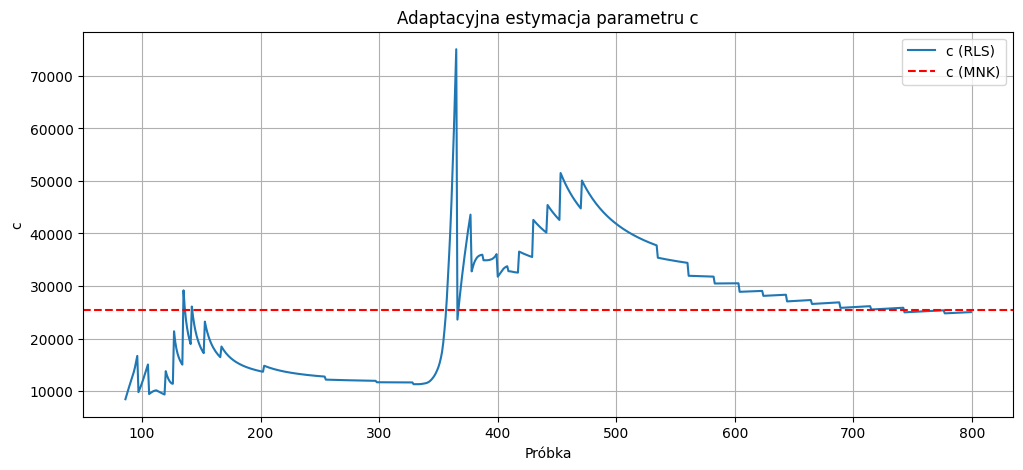

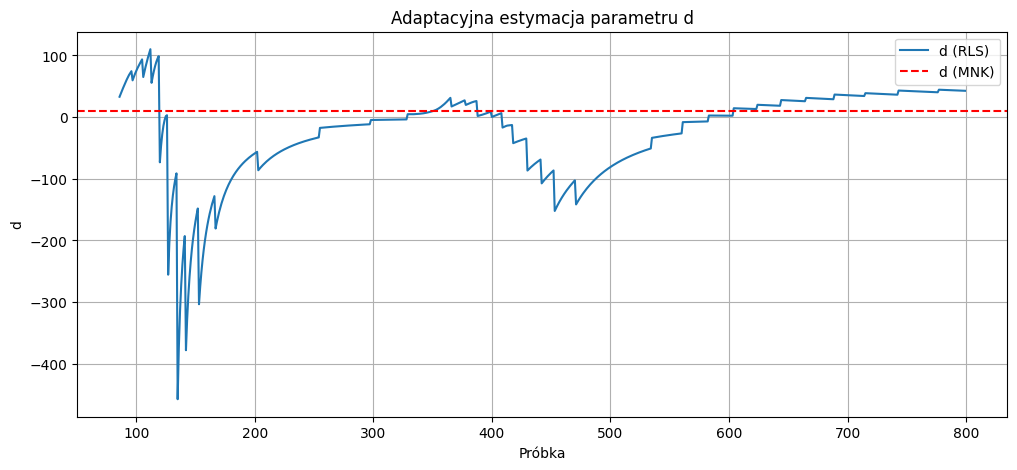

In [20]:
# ZADANIE 6 – ADAPTACYJNA IDENTYFIKACJA PARAMETRÓW (RLS)

def rls_identyfikacja(u, y, z, dt, lambda_f=0.995):
    N = len(y)

    theta = np.zeros(2)               # [a, b]
    P = np.eye(2) * 1000.0             # macierz kowariancji

    historia_c = np.zeros(N-1)
    historia_d = np.zeros(N-1)

    for n in range(N - 1):
        phi = np.array([u[n], z[n] - y[n]])
        y_model = y[n+1] - y[n]

        # RLS
        K = P @ phi / (lambda_f + phi.T @ P @ phi)
        blad = y_model - phi.T @ theta
        theta = theta + K * blad
        P = (P - np.outer(K, phi) @ P) / lambda_f

        a_hat, b_hat = theta

        if abs(a_hat) > 1e-8:
            historia_c[n] = dt / a_hat
            historia_d[n] = b_hat / a_hat
        else:
            historia_c[n] = np.nan
            historia_d[n] = np.nan

    return historia_c, historia_d


c_rls, d_rls = rls_identyfikacja(u_norm, y_norm, z_norm, dt)

plt.figure(figsize=(12, 5))
plt.plot(c_rls, label="c (RLS)")
plt.axhline(c_wynik, linestyle='--', label="c (MNK)", color = "red")
plt.xlabel("Próbka")
plt.ylabel("c")
plt.title("Adaptacyjna estymacja parametru c")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(d_rls, label="d (RLS)")
plt.axhline(d_wynik, linestyle='--', label="d (MNK)", color = "red")
plt.xlabel("Próbka")
plt.ylabel("d")
plt.title("Adaptacyjna estymacja parametru d")
plt.legend()
plt.grid(True)
plt.show()


Zbiegają parametry po czasie - może być realizowany przy stałym 